# B2 — Two-Hill Nested Consistency


        B2는 two-hill 환경에서 coverage 위치와 Stackelberg 위치를 고정한 뒤,
        L0/L1/L2와 action/speed/quadrature 변화를 비교한다. 핵심 질문은
        **격자를 바꿔도 경로와 두 sensor 후보의 순위가 얼마나 유지되는가**다.

In [1]:
from pathlib import Path
import json
from html import escape
import subprocess
import sys
from IPython.display import display, Markdown, Image, HTML, FileLink

def locate_repo_root():
    current = Path.cwd().resolve()
    for candidate in (current, *current.parents):
        if (candidate / "p1b_4D").is_dir() and (candidate / "p1b_roadmap_0729.md").exists():
            return candidate
    raise RuntimeError("glider_hybrid_control repository root를 찾지 못했습니다.")

ROOT = locate_repo_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
RESULTS = ROOT / "results"
STAGE = "B2"
STATUS = "COMPLETED"

def run_module(module, *arguments, timeout=None):
    command = [sys.executable, "-m", module, *map(str, arguments)]
    completed = subprocess.run(
        command, cwd=ROOT, text=True, stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT, timeout=timeout,
    )
    print(completed.stdout)
    if completed.returncode != 0:
        raise RuntimeError(f"{module} 실행 실패: exit={completed.returncode}")
    return completed.stdout

def load_json(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"결과 파일이 없습니다: {path}")
    return json.loads(path.read_text(encoding="utf-8"))

def show_png(path, width=1050):
    path = Path(path)
    if path.exists():
        display(Image(filename=str(path), width=width))
    else:
        display(Markdown(f"> ⚠️ 그림이 없습니다: `{path}`"))

def display_table(rows, columns=None):
    if isinstance(rows, dict):
        rows = [rows]
    rows = list(rows)
    if columns is None:
        columns = []
        for row in rows:
            for key in row:
                if key not in columns:
                    columns.append(key)
    if not rows:
        display(Markdown("_(표시할 행이 없습니다.)_"))
        return
    def cell(value):
        if isinstance(value, float):
            value = f"{value:.8g}"
        elif isinstance(value, (dict, list, tuple)):
            value = json.dumps(value, ensure_ascii=False)
        return escape(str(value))
    header = "".join(f"<th>{cell(name)}</th>" for name in columns)
    body = "".join(
        "<tr>" + "".join(f"<td>{cell(row.get(name, ''))}</td>" for name in columns) + "</tr>"
        for row in rows
    )
    display(HTML(
        "<div style='overflow-x:auto'><table>"
        f"<thead><tr>{header}</tr></thead><tbody>{body}</tbody></table></div>"
    ))

display(Markdown(f"**{STAGE} 상태:** `{STATUS}`  \nRepository: `{ROOT}`"))

**B2 상태:** `COMPLETED`  
Repository: `C:\Users\jeffe\Desktop\git\glider_hybrid_control`

In [2]:
RERUN = False  # True이면 18-case 전체를 다시 계산하므로 오래 걸립니다.
RESULT_PATH = RESULTS / "direction_b" / "b2_two_hill_nested_consistency.json"
FIGURE_DIR = RESULTS / "direction_b" / "figures"
if RERUN:
    run_module(
        "p1b_4D.experiment_b2_two_hill_nested_consistency",
        "--output", RESULT_PATH,
    )
result = load_json(RESULT_PATH)
display(Markdown(
    f"**상태:** `{result['status']}` · cases={result['case_count']} · "
    f"feasible={result['feasible_case_count']} · "
    f"common evaluator={result['global_common_evaluator_sample_count']}"
))

**상태:** `complete` · cases=18 · feasible=12 · common evaluator=1025

In [3]:
rows = []
for case in result["cases"]:
    if (
        case["action_family"] == "enriched"
        and case["speed_family"] == "V5"
        and case["planning_quadrature_count"] == 9
    ):
        rows.append({
            "sensor": case["sensor_name"],
            "level": f"L{case['level']}",
            "status": case["status"],
            "HF attacker objective": (
                case.get("selected_high_fidelity", {}).get("attacker_objective")
            ),
            "switch z": (
                case.get("planning", {}).get("switching_point", [None])[0]
            ),
            "path nodes": case.get("planning", {}).get("path_node_count"),
        })
display_table(rows)
display_table([
    {"metric": "ranking sign stable", "value": result["analysis"]["ranking_sign_stable"]},
    {"metric": "ranking diagnostically resolved", "value": result["analysis"]["ranking_diagnostically_resolved"]},
    {"metric": "production speed", "value": result["analysis"]["production_speed_family"]},
    {"metric": "production planning quadrature", "value": result["analysis"]["production_planning_quadrature_count"]},
])

sensor,level,status,HF attacker objective,switch z,path nodes
coverage,L0,feasible,2.4097978,0,29
coverage,L1,feasible,2.3985381,0,34
coverage,L2,feasible,2.2545884,8.59375,80
stackelberg,L0,feasible,3.4697982,34.375,29
stackelberg,L1,feasible,3.1710111,0,32
stackelberg,L2,feasible,3.0013666,8.59375,78


metric,value
ranking sign stable,True
ranking diagnostically resolved,True
production speed,V9
production planning quadrature,9


2026-07-30 09:44:53,454 | INFO | stackelberg | phase=Phase 1: Configuration status=started


2026-07-30 09:44:53,456 | WARNING | stackelberg | phase=Phase 1: Configuration warning=Vehicle segment_length is deferred to the future transcription contract instead of fabricating a Phase 1 value


2026-07-30 09:44:53,457 | INFO | stackelberg | phase=Phase 1: Configuration status=success elapsed_seconds=0.002219


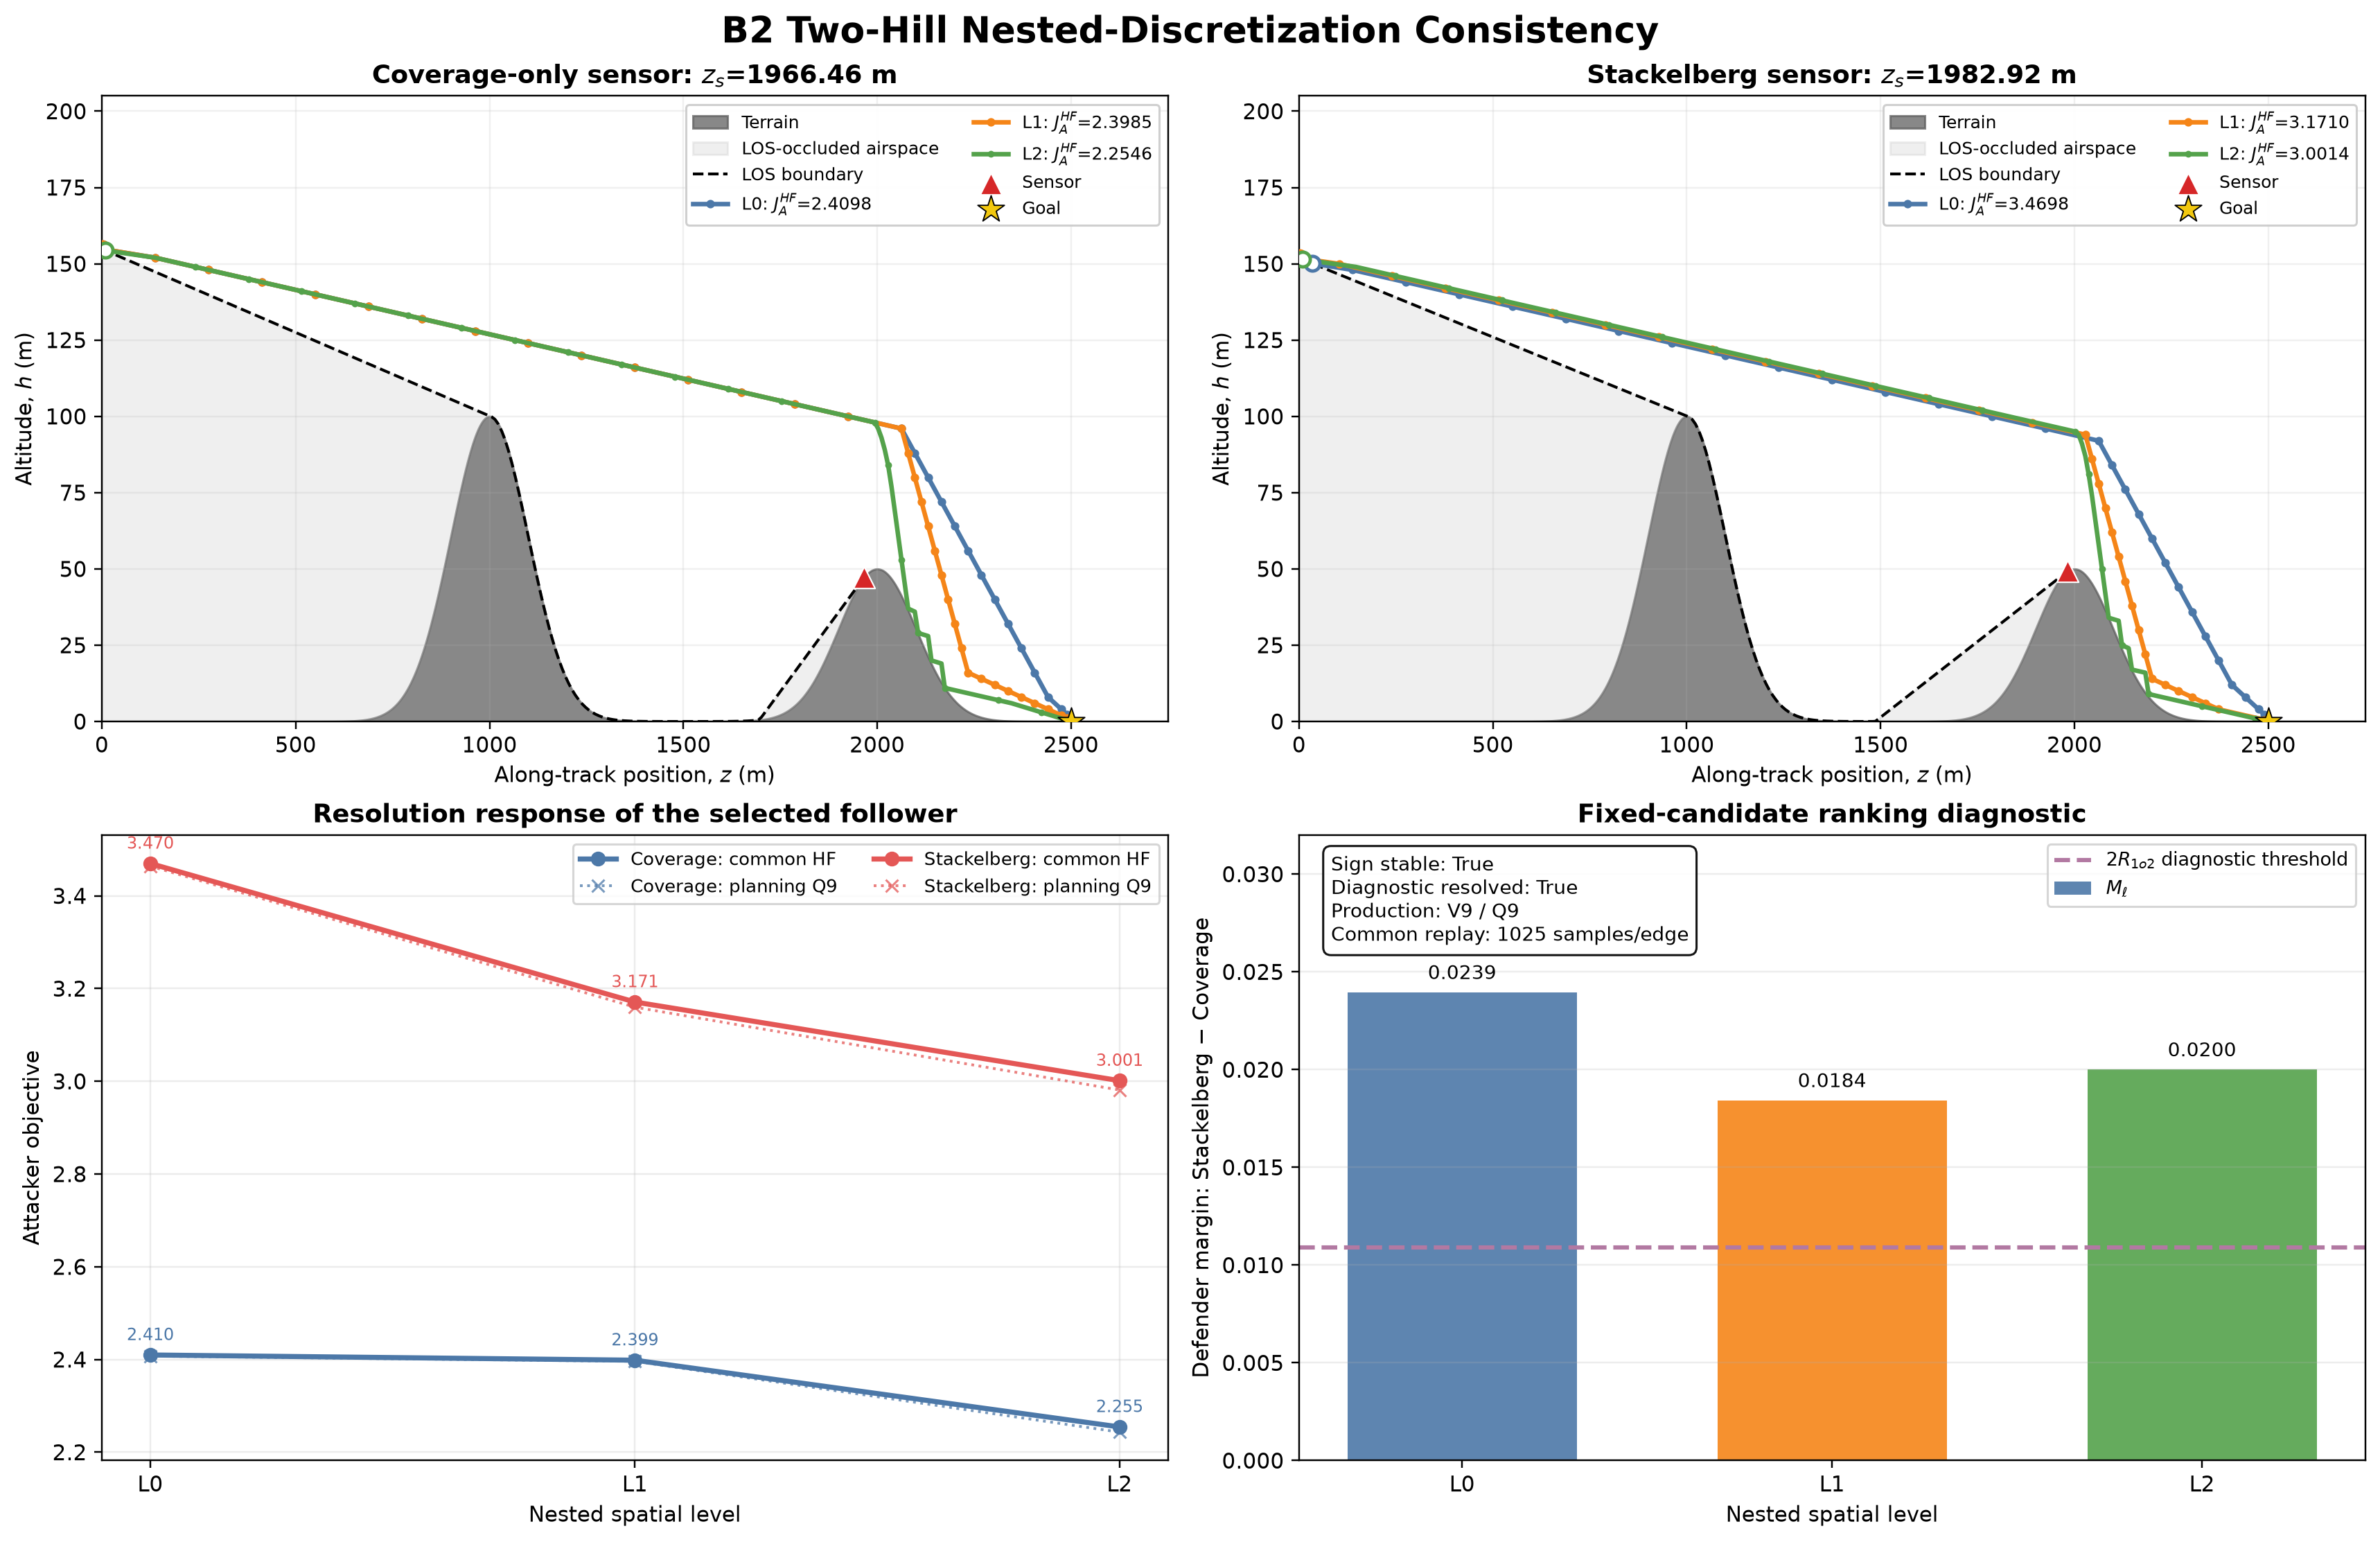

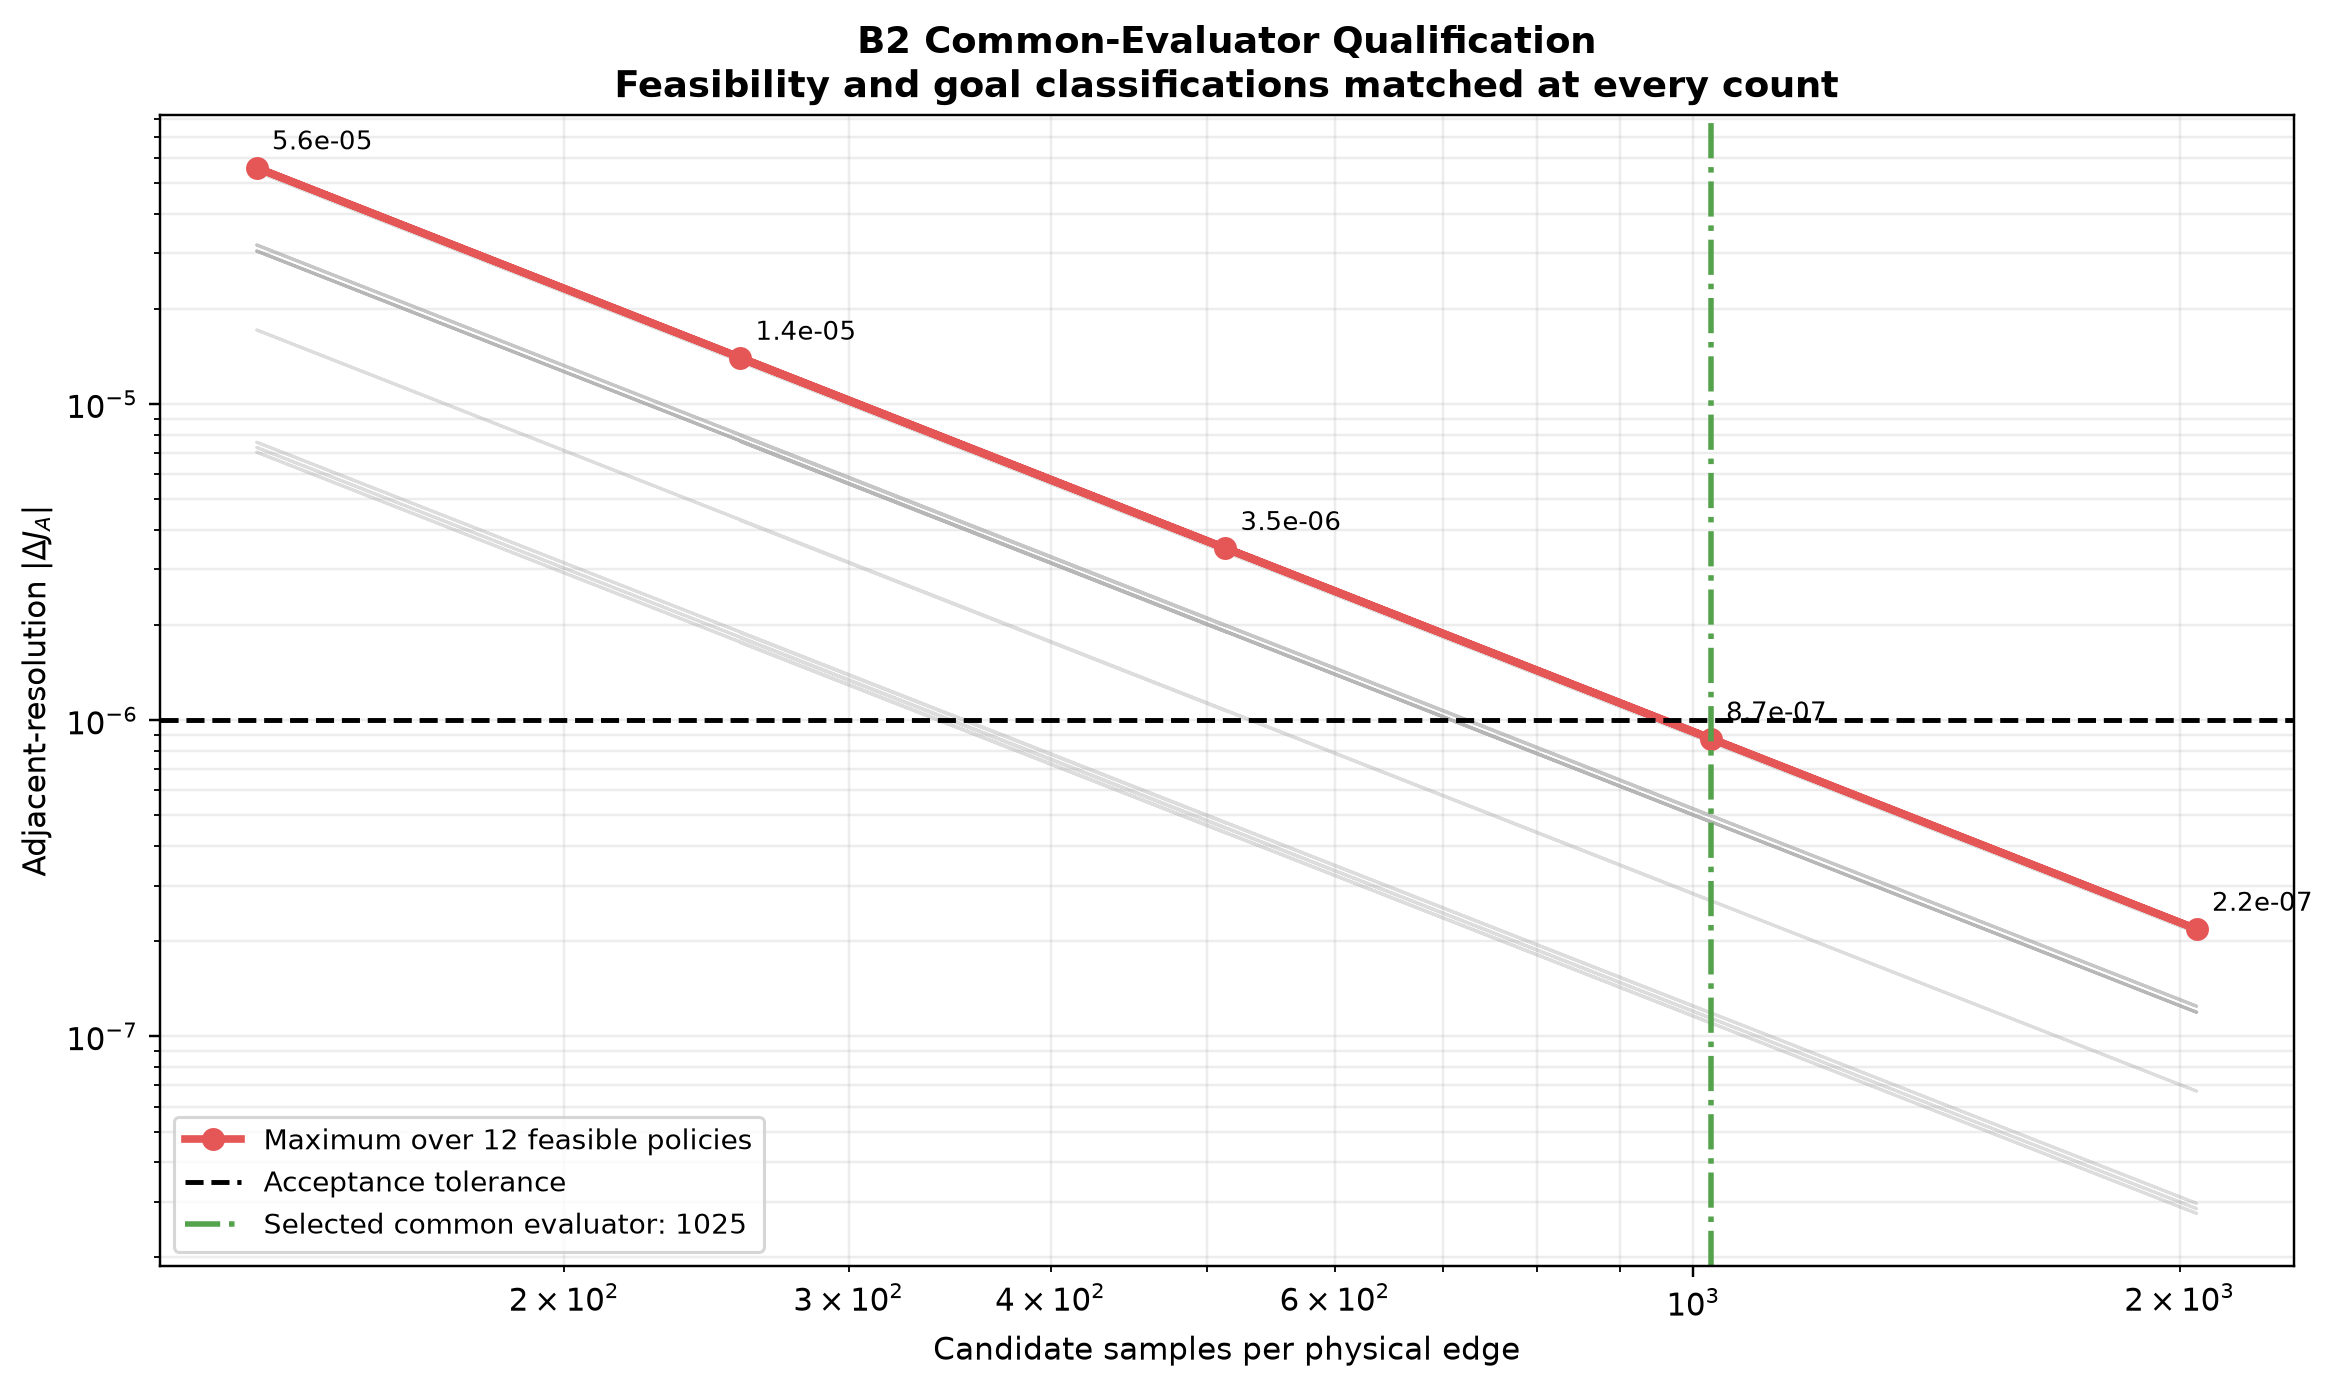

In [4]:
from p1b_4D.visualize_b2_two_hill_nested_consistency import create_b2_figures
figure_paths = create_b2_figures(RESULT_PATH, FIGURE_DIR, ROOT)
for figure_path in figure_paths:
    show_png(figure_path)

## 직관적 결론

모든 feasible 경로는 물리적으로 replay되지만 L1→L2 경로 변화는
아직 작지 않다. 다만 two-hill의 두 sensor 후보 순위 부호는
유지됐고, speed sensitivity 때문에 최종 production speed는 V9로
결정됐다.